In [ ]:
# Color map for the labels
abbr_to_color = {
    "BL": (0, 255, 255),
    "CL": (0, 128, 255),
    "DM": (178, 102, 255),
    "JB": (255, 255, 51),
    "LA": (255, 102, 178),
    "PC": (255, 255, 0),
    "RA": (255, 0, 127),
    "SA": (255, 0, 255),
    "SL": (0, 255, 0),
    "SLA": (255, 128, 0),
    "SRA": (255, 0, 0),
}


# Normalized version for matplotlib
abbr_to_color_normalized = {
    abbr: tuple(c / 255 for c in rgb) for abbr, rgb in abbr_to_color.items()
}

abbr_to_text = {
    "BL": "Bus Lane",
    "CL": "Cycle Lane",
    "DM": "Diamond",
    "JB": "Junction Box",
    "LA": "Left Arrow",
    "PC": "Pedestrian Crossing",
    "RA": "Right Arrow",
    "SA": "Straight Arrow",
    "SL": "Slow",
    "SLA": "Straight-Left Arrow",
    "SRA": "Straight-Right Arrow",
}

In [ ]:
# # Extract ResNet vectors from the shapes in the images
# # Save the vectors and labels to npy files
# # The vectors are 2048D vectors
# # The labels are the labels of the shapes
# # The images are the images in the train/images directory
# # The shapes are the shapes in the train/polygon_annotations directory
# # The vectors are extracted from the shapes in the images

# import os
# import json
# import numpy as np
# import cv2
# from PIL import Image
# import torch
# import torch.nn as nn
# from torchvision import models, transforms

# # Paths (adjust base_path if needed)
# base_path = "./"
# img_dir = os.path.join(base_path, "train/images")
# json_dir = os.path.join(base_path, "train/polygon_annotations")
# vectors_output = os.path.join(base_path, "train_shape_vectors.npy")
# labels_output = os.path.join(base_path, "train_shape_labels.npy")  # Labels as strings

# # Load pretrained ResNet-50
# model = models.resnet50(pretrained=True)
# model = nn.Sequential(
#     *list(model.children())[:-1]
# )  # Remove final layer for 2048D vectors, resnet50 has 2048D vectors
# model.eval()  # Evaluation mode

# # Image preprocessing for ResNet (resize to 224x224, normalize)
# preprocess = transforms.Compose(
#     [
#         transforms.Resize((224, 224)),
#         transforms.ToTensor(),
#         transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
#     ]
# )


# def extract_vector_from_shape(img_cv, points, label, padding_factor=0.1):
#     """Extract ResNet vector from a single shape's masked crop."""
#     # Compute bounding box with padding
#     points_np = np.array(points, dtype=np.float32)
#     x, y, w, h = cv2.boundingRect(points_np)
#     pad_w = int(w * padding_factor)
#     pad_h = int(h * padding_factor)
#     x = max(0, x - pad_w)
#     y = max(0, y - pad_h)
#     w += 2 * pad_w
#     h += 2 * pad_h

#     # Crop (ensure within image bounds)
#     crop = img_cv[y : y + h, x : x + w]
#     if crop.size == 0 or crop.shape[0] < 32 or crop.shape[1] < 32:
#         print(f"Skipping small crop for label '{label}' (size: {crop.shape})")
#         return None

#     # Create mask for this specific shape (relative to crop)
#     mask = np.zeros(crop.shape[:2], dtype=np.uint8)

#     # Shift points to crop coordinates
#     shifted_points = points_np - [x, y]

#     # Fills the mask with white
#     cv2.fillPoly(mask, [np.int32(shifted_points)], 255)

#     # Apply mask, keeping only the pixels inside the polygon, black out the rest
#     masked_crop = cv2.bitwise_and(crop, crop, mask=mask)

#     # Convert to PIL, preprocess, convert to tensor
#     img = Image.fromarray(cv2.cvtColor(masked_crop, cv2.COLOR_BGR2RGB))
#     img_tensor = preprocess(img).unsqueeze(0)

#     # Extract vector from the masked crop
#     with torch.no_grad():
#         vector = model(img_tensor).squeeze().numpy()  # 2048D vector
#     return vector


# # Process all test images and their shapes
# all_vectors = []
# all_labels = []
# img_files = sorted([f for f in os.listdir(img_dir) if f.endswith(".jpg")])
# for img_file in img_files:
#     img_path = os.path.join(img_dir, img_file)
#     json_file = os.path.splitext(img_file)[0] + ".json"
#     json_path = os.path.join(json_dir, json_file)

#     if not os.path.exists(json_path):
#         print(f"No JSON for {img_file}; skipping.")
#         continue

#     # Load image and JSON
#     img = Image.open(img_path).convert("RGB")
#     img_cv = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
#     with open(json_path, "r") as f:
#         data = json.load(f)

#     if not data["shapes"]:
#         print(f"No shapes in {json_file}; skipping.")
#         continue

#     print(f"Processing {img_file} with {len(data['shapes'])} shapes...")
#     for shape in data["shapes"]:
#         label = shape["label"]
#         points = shape["points"]
#         vector = extract_vector_from_shape(img_cv, points, label)
#         if vector is not None:
#             all_vectors.append(vector)
#             all_labels.append(label)

# # Save results
# np.save(vectors_output, np.array(all_vectors))
# np.save(labels_output, np.array(all_labels, dtype=object))  # Labels as strings
# print(
#     f"Saved {len(all_vectors)} vectors to {vectors_output} and labels to {labels_output}"
# )

In [ ]:
# # Visualize the shape polygons on the images for the first 10 files
# import matplotlib.pyplot as plt

# for img_file in img_files[0:10]:
#     img_path = os.path.join(img_dir, img_file)
#     json_file = os.path.splitext(img_file)[0] + ".json"
#     json_path = os.path.join(json_dir, json_file)

#     if not os.path.exists(json_path):
#         continue

#     img = Image.open(img_path).convert("RGB")
#     img_cv = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
#     with open(json_path, "r") as f:
#         data = json.load(f)

#     if not data["shapes"]:
#         continue

#     plt.figure(figsize=(20, 12))
#     plt.imshow(img)
#     ax = plt.gca()
#     for shape in data["shapes"]:
#         label = shape["label"]
#         points = np.array(shape["points"])
#         # Draw polygon
#         poly = plt.Polygon(
#             points,
#             fill=True,
#             alpha=0.3,
#             label=label,
#             color=abbr_to_color_normalized[label],
#         )
#         ax.add_patch(poly)
#         # Draw label at centroid
#         centroid = points.mean(axis=0)
#         plt.text(
#             centroid[0],
#             centroid[1],
#             abbr_to_text[label],
#             fontsize=10,
#             color=abbr_to_color_normalized[label],
#             weight="bold",
#         )
#     plt.title(f"Polygons for {img_file}")
#     plt.axis("off")
#     handles, labels_ = ax.get_legend_handles_labels()
#     by_label = dict(zip(labels_, handles))

#     if by_label:
#         plt.legend(
#             by_label.values(),
#             [abbr_to_text[label] for label in by_label.keys()],
#             loc="lower right",
#         )
#     plt.show()

In [ ]:
# # Train multiple models and compare their performance
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.decomposition import PCA
# from sklearn.manifold import TSNE
# import umap
# from sklearn.preprocessing import LabelEncoder, StandardScaler
# from sklearn.model_selection import train_test_split, cross_val_score
# from sklearn.svm import LinearSVC, SVC
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import classification_report

# # Step 1: Load vectors and labels
# vectors_file = './train_shape_vectors.npy'
# labels_file = './train_shape_labels.npy'
# vectors = np.load(vectors_file)
# labels = np.load(labels_file, allow_pickle=True)

# # Encode labels to integers
# le = LabelEncoder()
# encoded_labels = le.fit_transform(labels)

# # Step 2: Visualization for Separability Check
# # 2a: PCA (linear reduction) - if classes separate linearly here, good sign
# pca = PCA(n_components=2)
# vectors_pca = pca.fit_transform(vectors)

# plt.figure(figsize=(10, 8))
# plt.scatter(vectors_pca[:, 0], vectors_pca[:, 1], c=encoded_labels, cmap='viridis', alpha=0.7)
# plt.colorbar()
# plt.title('PCA: Check for Linear Separability')
# plt.xlabel('PC1')
# plt.ylabel('PC2')
# plt.show()

# # 2b: UMAP (non-linear) - compare to PCA; more mixing/clustering indicates non-linearity
# umap_model = umap.UMAP(n_components=2, random_state=42)
# vectors_umap = umap_model.fit_transform(vectors)

# plt.figure(figsize=(10, 8))
# plt.scatter(vectors_umap[:, 0], vectors_umap[:, 1], c=encoded_labels, cmap='viridis', alpha=0.7)
# plt.colorbar()
# plt.title('UMAP: Check for Non-Linear Patterns')
# plt.xlabel('UMAP1')
# plt.ylabel('UMAP2')
# plt.show()

# # Optional: t-SNE for another non-linear view
# tsne = TSNE(n_components=2, random_state=42)
# vectors_tsne = tsne.fit_transform(vectors)

# plt.figure(figsize=(10, 8))
# plt.scatter(vectors_tsne[:, 0], vectors_tsne[:, 1], c=encoded_labels, cmap='viridis', alpha=0.7)
# plt.colorbar()
# plt.title('t-SNE: Alternative Non-Linear View')
# plt.show()

# # Step 3: Model Comparison for Separability
# X_train, X_test, y_train, y_test = train_test_split(vectors, encoded_labels, test_size=0.2, random_state=42, stratify=encoded_labels)

# # Scale features (important for SVM)
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# # 3a: Linear Model (LinearSVC)
# linear_svc = LinearSVC(max_iter=10000, random_state=42)
# linear_scores = cross_val_score(linear_svc, X_train_scaled, y_train, cv=5, scoring='accuracy')
# print(f"LinearSVC Cross-Val Accuracy: {linear_scores.mean():.2f} (+/- {linear_scores.std():.2f})")

# linear_svc.fit(X_train_scaled, y_train)
# y_pred_linear = linear_svc.predict(X_test_scaled)
# print("LinearSVC Test Report:\n", classification_report(y_test, y_pred_linear))

# # 3b: Non-Linear Models
# # SVM with RBF kernel (non-linear)
# rbf_svc = SVC(kernel='rbf', random_state=42)
# rbf_scores = cross_val_score(rbf_svc, X_train_scaled, y_train, cv=5, scoring='accuracy')
# print(f"RBF SVC Cross-Val Accuracy: {rbf_scores.mean():.2f} (+/- {rbf_scores.std():.2f})")

# rbf_svc.fit(X_train_scaled, y_train)
# y_pred_rbf = rbf_svc.predict(X_test_scaled)
# print("RBF SVC Test Report:\n", classification_report(y_test, y_pred_rbf))

# # Random Forest (non-linear ensemble)
# rf = RandomForestClassifier(n_estimators=100, random_state=42)
# rf_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')  # RF doesn't need scaling
# print(f"Random Forest Cross-Val Accuracy: {rf_scores.mean():.2f} (+/- {rf_scores.std():.2f})")

# rf.fit(X_train, y_train)
# y_pred_rf = rf.predict(X_test)
# print("Random Forest Test Report:\n", classification_report(y_test, y_pred_rf))

# # Interpretation Notes (printed for reference):
# print("\nAnalysis:")
# print("- If LinearSVC accuracy is high and close to non-linear models, classes may be linearly separable.")
# print("- If RBF SVC or RF significantly outperform LinearSVC, relationships are likely non-linear.")
# print("- Check visualizations: Linear separation in PCA but not UMAP/t-SNE suggests non-linearity.")

#### Based on the graph and the training result, we can assume that the data is linearly separable, therefore, we will proceed with LinearSVC and start tuning

In [ ]:
# # Tuning Linear SVC
# from sklearn.model_selection import GridSearchCV
# import joblib
# from sklearn.preprocessing import LabelEncoder, StandardScaler
# from sklearn.model_selection import train_test_split
# from sklearn.svm import LinearSVC
# from sklearn.metrics import classification_report
# import numpy as np

# vectors_file = "./train_shape_vectors.npy"
# labels_file = "./train_shape_labels.npy"
# vectors = np.load(vectors_file)
# labels = np.load(labels_file, allow_pickle=True)


# le = LabelEncoder()
# encoded_labels = le.fit_transform(labels)

# # Fix: Correct variable assignment for train_test_split
# X_train, X_test, y_train, y_test = train_test_split(
#     vectors, encoded_labels, test_size=0.2, random_state=42, stratify=encoded_labels
# )

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# linear_svc = LinearSVC(max_iter=10000, random_state=42)

# param_grid = {
#     "C": [0.01, 0.1, 1, 10, 100],  # Smaller C = more regularization (less overfitting)
#     "class_weight": [None, "balanced"],  # 'balanced' for class imbalance
# }

# # Run GridSearchCV (5-fold CV on train data)
# grid_search = GridSearchCV(
#     estimator=linear_svc,
#     param_grid=param_grid,
#     cv=5,
#     scoring="f1_macro",
#     n_jobs=-1,
#     verbose=1,
# )
# grid_search.fit(X_train_scaled, y_train)

# # Get best model and evaluate on validation set
# best_model = grid_search.best_estimator_
# print(f"Best Parameters: {grid_search.best_params_}")
# print(f"Best Cross-Val F1-Macro Score: {grid_search.best_score_:.2f}")

# y_pred = best_model.predict(X_test_scaled)
# print("Test Report:\n", classification_report(y_test, y_pred))

# # Save the best model, scaler, and label encoder
# joblib.dump(best_model, "tuned_linear_svc.joblib")
# joblib.dump(scaler, "scaler.joblib")
# joblib.dump(le, "label_encoder.joblib")
# print("Model, scaler, and label encoder saved.")

### Let's test on images that have not been used for training or testing

In [ ]:
# training yolo to detect road markings, we will use this to help with object detection
from ultralytics import YOLO

model = YOLO('yolov8n-seg.pt')  # Pretrained on COCO; will fine-tune on your data


results = model.train(
    data='./data.yaml',  # Your data config file
    epochs=50,           # Adjust based on dataset size/convergence
    imgsz=640,           # Training image size
    batch=16,            # Batch size (adjust for your hardware)
    device='cpu',        # Change to '0' if GPU available
    workers=4,           # Data loading threads
    patience=50,         # Early stopping if no improvement
    name='road_markings_train',  # Run name for organization
    verbose=True         # Detailed logging
)

/Users/anhngo/.pyenv/versions/3.10.11/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/anhngo/.pyenv/versions/3.10.11/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



0: 480x640 11 persons, 6 motorcycles, 1 truck, 62.9ms
Speed: 2.1ms preprocess, 62.9ms inference, 6.3ms postprocess per image at shape (1, 3, 480, 640)


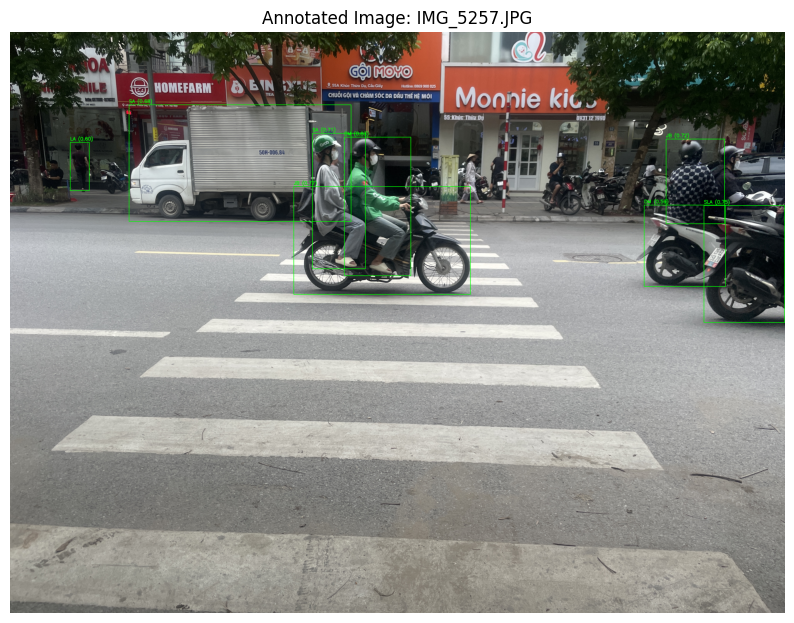

In [3]:
# Predicting on new images
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import models, transforms
import joblib
import numpy as np
import cv2
from PIL import Image
import os
from ultralytics import YOLO

# Load saved model, scaler, and label encoder
model_file = "./tuned_linear_svc.joblib"
scaler_file = "./scaler.joblib"
label_encoder_file = "./label_encoder.joblib"

classifier = joblib.load(model_file)
scaler = joblib.load(scaler_file)
le = joblib.load(label_encoder_file)

resnet_model = models.resnet50(pretrained=True)
resnet_model = nn.Sequential(*list(resnet_model.children())[:-1])
resnet_model.eval()

# Preprocessing for ResNet
preprocess = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

yolo_model_path = "./yolov8n-seg.pt"
yolo = YOLO(yolo_model_path)


def visualize_predictions_with_detection(img_path, conf_threshold=0.5):
    # Load image
    img = Image.open(img_path).convert("RGB")
    img_cv = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)  # OpenCV format for drawing
    img_annotated = img_cv.copy()

    # Run YOLO detection (returns list of detections with boxes)
    results = yolo(img_cv)[0]  # Run inference

    detections_found = False
    for result in results.boxes:
        # Get box coordinates and confidence
        x1, y1, x2, y2 = map(int, result.xyxy[0])  # Bounding box
        conf = result.conf[0]  # Confidence score

        if conf < conf_threshold:
            continue  # Skip low-confidence detections

        detections_found = True

        # Crop the detected region
        crop = img_cv[y1:y2, x1:x2]
        if crop.size == 0 or crop.shape[0] < 32 or crop.shape[1] < 32:
            continue  # Skip small crops

        # Extract vector from crop (no mask, as YOLO provides region)
        pil_crop = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        crop_tensor = preprocess(pil_crop).unsqueeze(0)
        with torch.no_grad():
            vector = resnet_model(crop_tensor).squeeze().numpy()

        # Predict label
        scaled_vector = scaler.transform([vector])
        prediction_encoded = classifier.predict(scaled_vector)
        prediction_decoded = le.inverse_transform(prediction_encoded)[0]

        # Draw bounding box and label
        cv2.rectangle(img_annotated, (x1, y1), (x2, y2), (0, 255, 0), 2)  # Green box
        cv2.putText(
            img_annotated,
            f"{prediction_decoded} ({conf:.2f})",
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 255, 0),
            2,
        )

    if not detections_found:
        print(f"No high-confidence detections in {img_path}; skipping boxes.")

    # Step 5: Plot with matplotlib
    img_annotated_rgb = cv2.cvtColor(img_annotated, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 8))
    plt.imshow(img_annotated_rgb)
    plt.axis("off")
    plt.title(f"Annotated Image: {os.path.basename(img_path)}")
    plt.show()


# Step 6: Example usage
img_path = "./validation/IMG_5257.JPG"  # Your new image file

visualize_predictions_with_detection(img_path, conf_threshold=0.5)


# Process a directory of new images
# new_images_dir = "./validation"
# for img_file in os.listdir(new_images_dir):
#     if not img_file.lower().endswith((".jpg", ".JPG", ".jpeg", ".png")):
#         continue
#     img_path = os.path.join(new_images_dir, img_file)

#     print(f"Processing {img_path}...")

#     predicted_label = visualize_prediction_on_image(img_path)
#     print(f"Predicted label for {img_path}: {predicted_label}")
#     print("-" * 50)

In [ ]:
import os
import json
from PIL import Image

# Step 1: Define class map (from your earlier code; adjust if needed)
class_map = {
    "BL": 0,  # Bus Lane
    "CL": 1,  # Cycle Lane
    "DM": 2,  # Diamond
    "JB": 3,  # Junction Box
    "LA": 4,  # Left Arrow
    "PC": 5,  # Pedestrian Crossing
    "RA": 6,  # Right Arrow
    "SA": 7,  # Straight Arrow
    "SL": 8,  # Slow
    "SLA": 9,  # Straight-Left Arrow
    "SRA": 10,  # Straight-Right Arrow
}

# Step 2: Function to convert polygon JSONs to YOLO segmentation labels
def convert_polygons_to_yolo(json_dir, img_dir, label_dir, class_map):
    os.makedirs(label_dir, exist_ok=True)  # Create labels folder if missing
    for json_file in os.listdir(json_dir):
        if not json_file.endswith('.json'):
            continue
        json_path = os.path.join(json_dir, json_file)
        with open(json_path, 'r') as f:
            data = json.load(f)
        
        img_id = os.path.splitext(json_file)[0]
        img_path = os.path.join(img_dir, f'{img_id}.jpg')  # Assume .jpg; adjust if needed
        if not os.path.exists(img_path):
            print(f"No image for {json_file}; skipping.")
            continue
        
        # Get image dimensions for normalization
        img = Image.open(img_path)
        width, height = img.size
        
        # Create .txt label file
        txt_path = os.path.join(label_dir, f'{img_id}.txt')
        with open(txt_path, 'w') as txt_f:
            for shape in data['shapes']:
                class_label = shape['label']  # e.g., 'PC'
                class_id = class_map.get(class_label, -1)  # -1 if unknown
                if class_id == -1:
                    print(f"Warning: Unknown class '{class_label}' in {json_file}")
                    continue
                points = shape['points']
                # Normalize and flatten: class_id x1 y1 x2 y2 ... (x normalized by width, y by height)
                normalized = [class_id] + [coord / width if i % 2 == 0 else coord / height 
                                           for point in points for i, coord in enumerate(point)]
                txt_f.write(' '.join(map(str, normalized)) + '\n')
    print(f"Converted labels saved to {label_dir}")

# Step 3: Run conversion for train and test
base_path = './'  # Your project root

# For train
convert_polygons_to_yolo(
    os.path.join(base_path, 'train/polygon_annotations'),
    os.path.join(base_path, 'train/images'),
    os.path.join(base_path, 'train/labels'),  # Creates this folder
    class_map
)

# For test (used as val)
convert_polygons_to_yolo(
    os.path.join(base_path, 'test/polygon_annotations'),
    os.path.join(base_path, 'test/images'),
    os.path.join(base_path, 'test/labels'),  # Creates this folder
    class_map
)

# Notes:
# - This generates .txt files in YOLO segmentation format (class_id followed by normalized polygon points).
# - Assumes images are .jpg; adjust extension if needed.
# - If JSON has multiple shapes, each becomes a line in .txt.
# - After running, verify a sample .txt matches the JSON (e.g., normalized coords between 0-1).
# - Now you can train YOLO as in previous code.